# Project 7 — Skin Cancer Detection

**Dataset:** HAM10000  
**Target:** >80% Melanoma Recall  
**Model:** EfficientNetV2-S (Transfer Learning, Fine-Tuned)

## 7. Model Architecture

In [32]:
# EfficientNetV2-S: better accuracy/speed tradeoff than DenseNet121
model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, len(CLASS_NAMES))
)
model = model.to(DEVICE)

# ── Loss: label-smoothed cross entropy with class weights ────────────────────
# Focal loss caused near-zero loss values with the imbalanced alpha — switching
# to weighted CE + label smoothing is more stable and easier to tune.
class_weights = torch.tensor(1.0 / np.sqrt(counts + 1), dtype=torch.float32)
class_weights = (class_weights / class_weights.sum() * len(CLASS_NAMES)).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Two-phase LR: lower LR for frozen backbone features, higher for head
head_params     = list(model.classifier.parameters())
backbone_params = [p for p in model.parameters() if not any(p is q for q in head_params)]

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.1},
    {'params': head_params,     'lr': LR}
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=[LR * 0.1, LR],
    steps_per_epoch=len(train_dl), epochs=EPOCHS, pct_start=0.2
)

print(f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Params: 20,186,455


## 8. Evaluation Helper

In [33]:
def evaluate(loader):
    """Returns loss, overall accuracy, and melanoma recall."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    mel_tp, mel_fn = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, labels)
            preds = out.argmax(1)
            total_loss += loss.item() * len(imgs)
            correct    += (preds == labels).sum().item()
            n          += len(imgs)
            is_mel      = labels == MEL_IDX
            mel_tp     += (preds[is_mel] == MEL_IDX).sum().item()
            mel_fn     += (preds[is_mel] != MEL_IDX).sum().item()
    mel_recall = mel_tp / (mel_tp + mel_fn + 1e-9)
    return total_loss / n, correct / n, mel_recall

## 9. Training

### 9.1 Training Loop

In [34]:
best_mel_recall = 0.0
history = []

print(f'{"Ep":>4} | {"Tr Loss":>8} {"Tr Acc":>7} | {"Vl Loss":>8} {"Vl Acc":>7} | {"Mel Rec":>7}')
print('-' * 62)

for ep in range(1, EPOCHS + 1):
    # ── train
    model.train()
    tr_loss, tr_correct, tr_n = 0.0, 0, 0
    for imgs, labels in train_dl:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        tr_loss    += loss.item() * len(imgs)
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_n       += len(imgs)

    tr_loss /= tr_n
    tr_acc   = tr_correct / tr_n

    # ── validate
    vl_loss, vl_acc, mel_rec = evaluate(val_dl)
    history.append((tr_loss, tr_acc, vl_loss, vl_acc, mel_rec))

    tag = ''
    if mel_rec > best_mel_recall:
        best_mel_recall = mel_rec
        torch.save(model.state_dict(), SAVE_PATH)
        tag = '  ✓'

    print(f'{ep:>4} | {tr_loss:>8.4f} {tr_acc:>7.3f} | {vl_loss:>8.4f} {vl_acc:>7.3f} | {mel_rec:>7.3f}{tag}')

print(f'\nBest val melanoma recall: {best_mel_recall:.3f}')

  Ep |  Tr Loss  Tr Acc |  Vl Loss  Vl Acc | Mel Rec
--------------------------------------------------------------
   1 |   2.0644   0.230 |   2.2124   0.353 |   0.194  ✓
   2 |   1.9272   0.314 |   2.0537   0.387 |   0.306  ✓
   3 |   1.5403   0.512 |   1.7607   0.609 |   0.581  ✓
   4 |   1.2524   0.663 |   1.6069   0.722 |   0.613  ✓
   5 |   1.0986   0.733 |   1.5340   0.742 |   0.661  ✓
   6 |   1.0231   0.779 |   1.5294   0.774 |   0.565
   7 |   0.9505   0.806 |   1.5385   0.767 |   0.629
   8 |   0.8963   0.829 |   1.5134   0.790 |   0.484
   9 |   0.8754   0.850 |   1.5442   0.762 |   0.710  ✓
  10 |   0.8420   0.869 |   1.4840   0.817 |   0.694
  11 |   0.8344   0.877 |   1.4978   0.811 |   0.565
  12 |   0.8017   0.894 |   1.5110   0.815 |   0.629
  13 |   0.7916   0.900 |   1.4754   0.838 |   0.597
  14 |   0.7722   0.902 |   1.5075   0.819 |   0.677
  15 |   0.7642   0.914 |   1.5266   0.813 |   0.597
  16 |   0.7605   0.916 |   1.5156   0.813 |   0.613
  17 |   0.7507   

### 9.2 Best Epoch Summary

In [42]:
h = np.array(history)
best_ep = int(h[:, 4].argmax()) + 1
print(f"Best Epoch : {best_ep}/{EPOCHS}")
print(f"Train Loss : {h[best_ep-1, 0]:.4f}  |  Train Acc : {h[best_ep-1, 1]:.3f}")
print(f"Val Loss   : {h[best_ep-1, 2]:.4f}  |  Val Acc   : {h[best_ep-1, 3]:.3f}")
print(f"Mel Recall : {h[best_ep-1, 4]:.3f}")

Best Epoch : 9/25
Train Loss : 0.8754  |  Train Acc : 0.850
Val Loss   : 1.5442  |  Val Acc   : 0.762
Mel Recall : 0.710


### 9.3 Training Curves

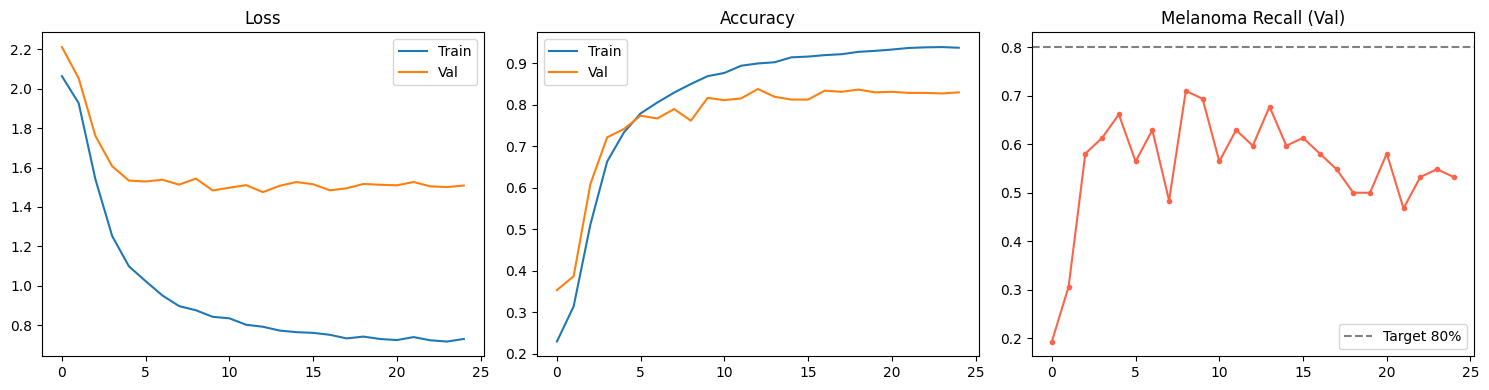

In [35]:
h = np.array(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(h[:,0], label='Train'); axes[0].plot(h[:,2], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(h[:,1], label='Train'); axes[1].plot(h[:,3], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()
axes[2].plot(h[:,4], color='tomato', marker='o', markersize=3)
axes[2].axhline(0.80, linestyle='--', color='gray', label='Target 80%')
axes[2].set_title('Melanoma Recall (Val)'); axes[2].legend()
plt.tight_layout(); plt.show()